In [1]:
import sys
sys.path.insert(0, '..')
from model.data import getMyData, getDataETTh1
from model.embedding import DataEmbedding
from model.encoder import EncoderInf, ConvLayer, EncoderInfLayer
from model.decoder import DecoderInfLayer, DecoderInf
from model.attention import AttentionLayer,ProbAttention,FullAttention
from model.utils import Normalize

import torch_ep.embed as epEmbed
import torch_ep.encoder as epEncoder
import torch

import numpy  as np
import tensorflow as tf
import math
import pandas as pd

from tensorflow.keras.layers import Dense,LayerNormalization
from keras.backend import softmax

import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

2024-09-05 19:03:29.790899: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2024-09-05 19:03:29.790931: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2024-09-05 19:03:29.790936: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2024-09-05 19:03:29.790972: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-09-05 19:03:29.790985: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Encoder .............
training True
(32, 96, 512)
training True
2
decoder ..........
(32, 72, 7)
prediction (32, 24, 7)
(24,)
(24,)


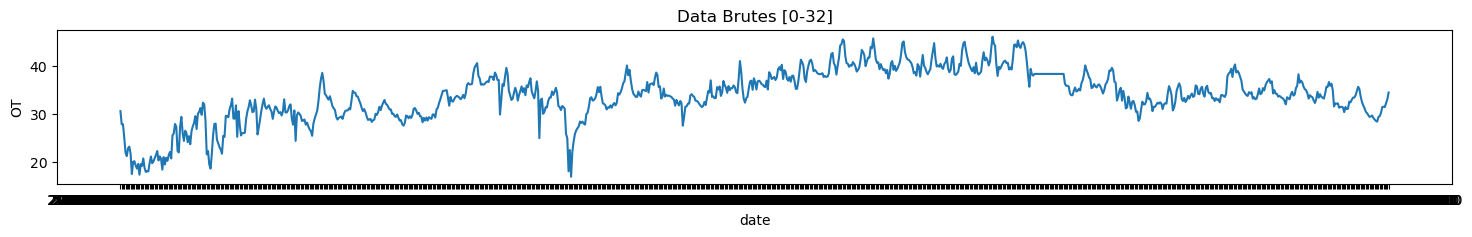

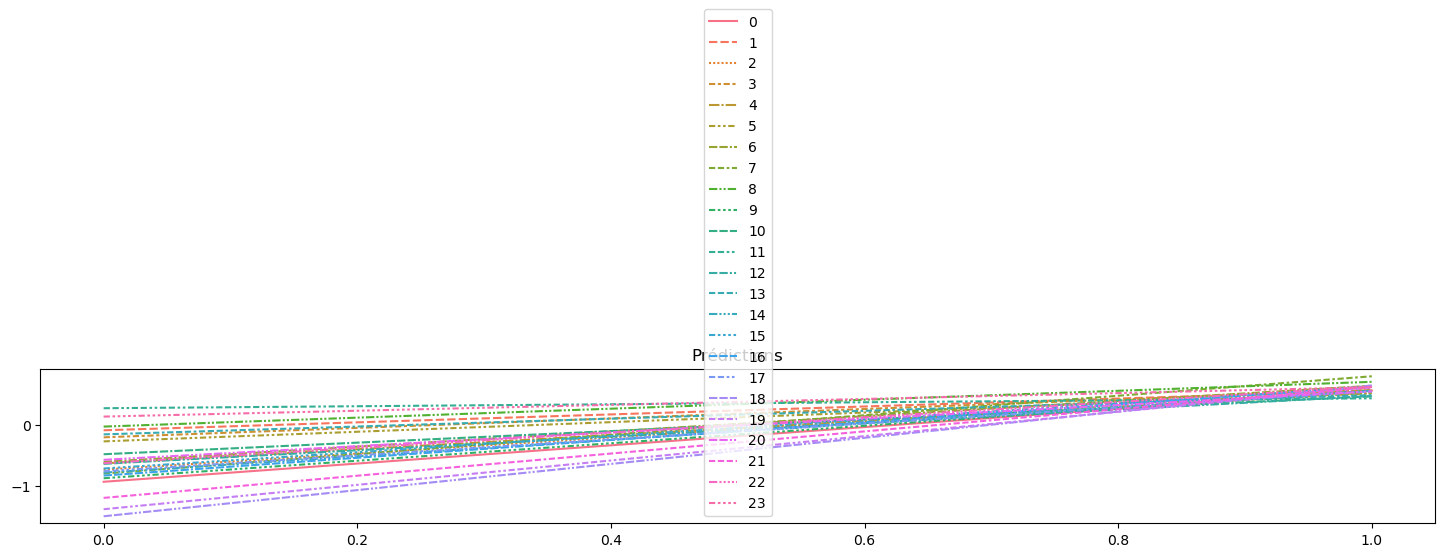

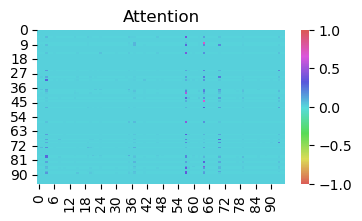

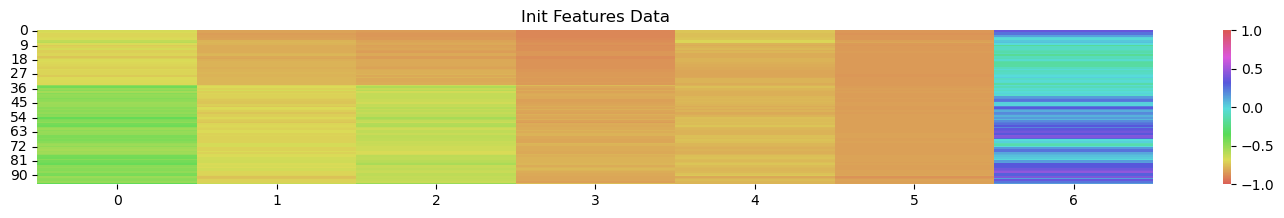

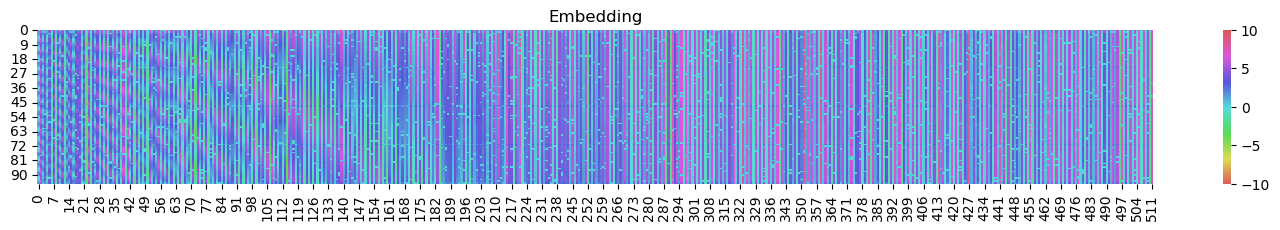

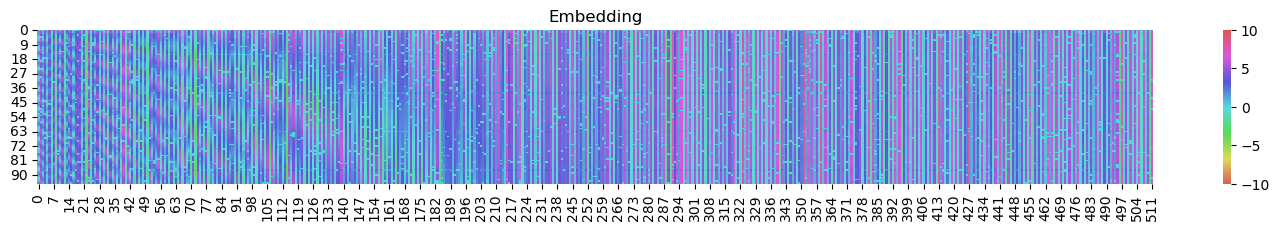

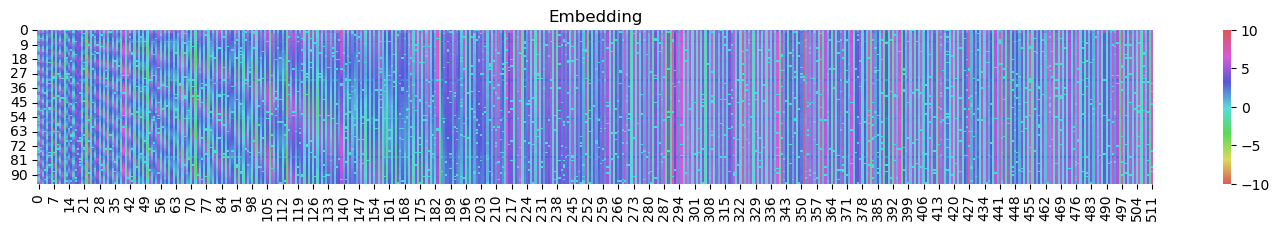

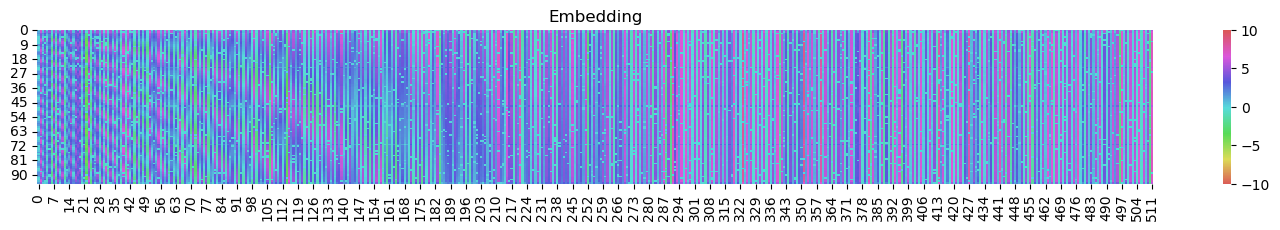

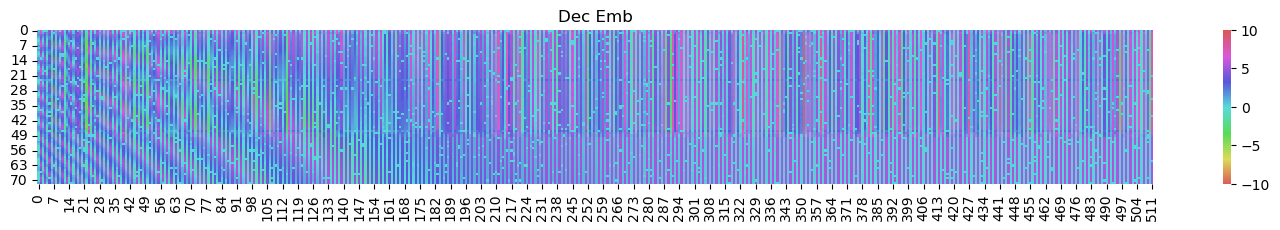

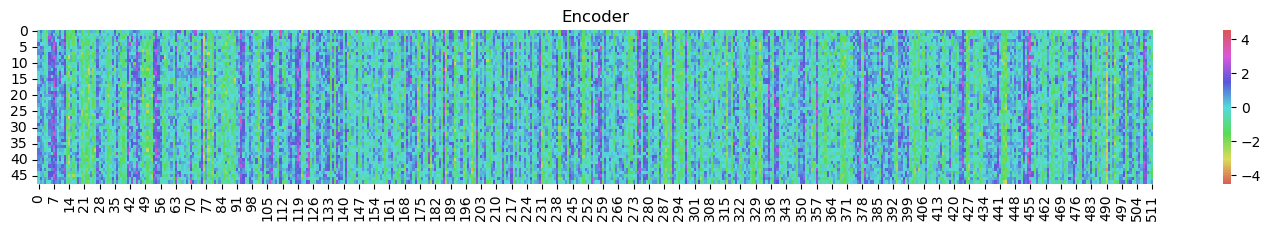

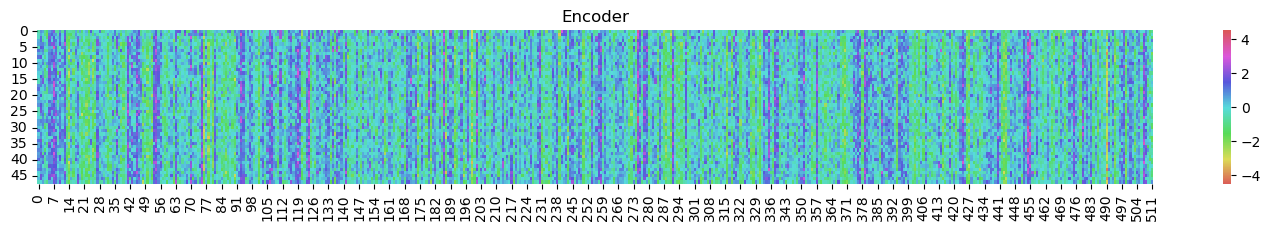

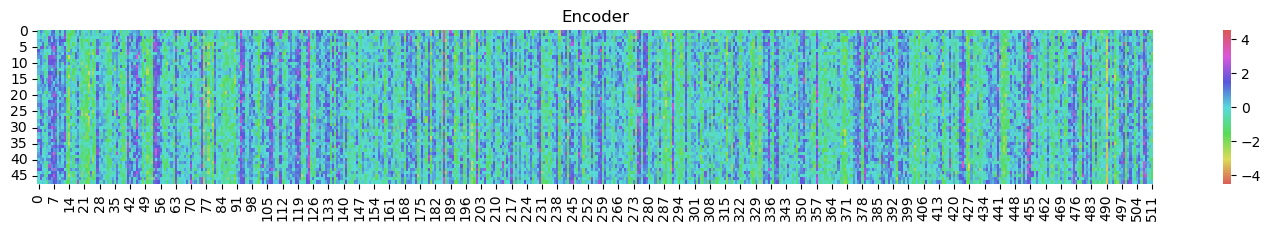

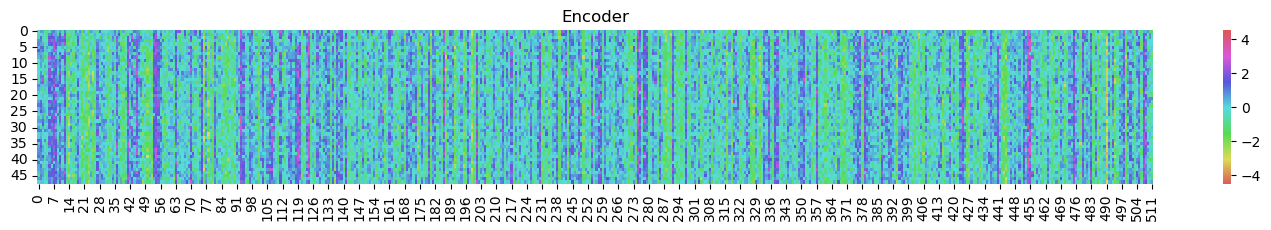

In [2]:
# Encoder
d_model = 512
HEAD = 8
RATE = 0.05
SEQ_LEN = 96
FACTOR = 5
BATCH_SIZE = 32
GLOBAL_SIZE = 1000
N = 2
d_FF= 2048

ENC_LEN = 96
DEC_LEN = 48
DEC_Padding =24

tf.keras.backend.clear_session()

# Get DATA
dataFct = getDataETTh1(SEQ_LEN,GLOBAL_SIZE)
x, x_date, Yt, YtDate, df_raw = dataFct.get()

# Prepare DATA
start = np.random.randint(0,GLOBAL_SIZE-BATCH_SIZE)
x,scaler = Normalize(tf.reshape(x, [GLOBAL_SIZE,-1]))
x = tf.reshape(x,[GLOBAL_SIZE,SEQ_LEN,7])
x = tf.cast(x,tf.float32)
x_date,scaler = Normalize(tf.reshape(x_date,[GLOBAL_SIZE,-1]))
x_date = tf.reshape(x_date,[GLOBAL_SIZE,SEQ_LEN,4])
x_date = tf.cast(x_date,tf.float32)

x_enc, x_date_enc = [ x[start:start+BATCH_SIZE,:ENC_LEN,:] , x_date[start:start+BATCH_SIZE,:ENC_LEN,:]]
x_dec, x_date_dec = [ x[start:start+BATCH_SIZE,:DEC_LEN,:] , x_date[start:start+BATCH_SIZE,:DEC_LEN,:]]
x_dec_padd = tf.zeros(shape=(BATCH_SIZE,DEC_Padding,x.shape[-1]))
x_date_dec_padd = tf.zeros(shape=(BATCH_SIZE,DEC_Padding,x_date.shape[-1]))
x_dec = tf.concat([x_dec,x_dec_padd],1)
x_date_dec = tf.concat([x_date_dec,x_date_dec_padd],1)

#Embedding
EmbFct = DataEmbedding(seq_len=SEQ_LEN, d_model=d_model,rate=RATE,timeF=True)
encEmb = EmbFct(x=x_enc, x_mark=x_date_enc, training=True)
decEmb = EmbFct(x=x_dec, x_mark=x_date_dec, training =True)

e_layer = 2

print('Encoder .............')
encTest = EncoderInf( [ EncoderInfLayer( 
                        AttentionLayer(
                            ProbAttention(False,FACTOR,None,RATE,True)
                                ,d_model, HEAD, None, None, False)
                            ,d_model, RATE,d_FF) for _ in range(e_layer) 
                        ]                     ,
                    [ ConvLayer(seq_len=SEQ_LEN) for _ in range (e_layer - 1)
                    ])

out,attn = encTest(encEmb, training=True)
print(len(attn))
print('decoder ..........')
decTest = DecoderInf( DecoderInfLayer (
                        AttentionLayer(
                            ProbAttention(False,FACTOR,None,RATE,True)
                                ,d_model,HEAD,None,None,False),
                        AttentionLayer(
                            FullAttention(False,FACTOR,None,RATE,False)
                                ,d_model, HEAD, None, None, False)
                        ,d_model,None,RATE,'relu')
                    ,norm_layer= LayerNormalization()
                   )
projection = Dense(7)

outDec = decTest(decEmb, out,training=True)
outDec = projection(outDec)
print(outDec.shape)
outInf = outDec[:,-24:,:]
print('prediction',outInf.shape)
print(outInf[0,:,-1].shape)
print(x_enc[0,-48:-24,-1].shape)
df = pd.DataFrame(np.vstack((outInf[0,:,-1],x_enc[0,-48:-24,-1]))) #,columns=['Pred','Vrai'])
Xt_min = tf.reduce_min(x)
Xt_max = tf.reduce_max(x)
Out_min = tf.reduce_min(out)
Out_max = tf.reduce_max(out)
fig = plt.figure(figsize=(18,2))
sns.lineplot(x=df_raw['date'][:GLOBAL_SIZE],y=df_raw['OT'][:GLOBAL_SIZE]).set_title('Data Brutes [0-32]');
fig = plt.figure(figsize=(18,2))
sns.lineplot(df).set_title('Prédictions');
# sns.lineplot(outInf[0,:,-1]).set_title('Prédictions');
fig = plt.figure(figsize=(4,2))
sns.heatmap(attn[0][0,0,:,:], vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('Attention');
fig = plt.figure(figsize=(18,2))
sns.heatmap(x[0,:,:], vmin=Xt_min, vmax=Xt_max, cmap=sns.color_palette("hls", 256)).set_title('Init Features Data');
for i in range(0,BATCH_SIZE,8):
    fig = plt.figure(figsize=(18,2))
    sns.heatmap(encEmb[i,:,:], vmin=-10, vmax=10, cmap=sns.color_palette("hls", 256)).set_title('Embedding');
for i in range(0,BATCH_SIZE,32):
    fig = plt.figure(figsize=(18,2))
    sns.heatmap(decEmb[i,:,:], vmin=-10, vmax=10, cmap=sns.color_palette("hls", 256)).set_title('Dec Emb');
for i in range(0,BATCH_SIZE,8):
    fig = plt.figure(figsize=(18,2))
    sns.heatmap(out[i,:,:], vmin=Out_min, vmax=Out_max, cmap=sns.color_palette("hls", 256)).set_title('Encoder');# for i in range(0,BATCH_SIZE,8):
